In [3]:
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# --- Load saved models and scaler ---
models = {
    'Logistic Regression': joblib.load('../models/logistic_regression.pkl'),
    'Decision Tree': joblib.load('../models/decision_tree.pkl'),
    'Random Forest': joblib.load('../models/random_forest.pkl'),
    'XGBoost': joblib.load('../models/xgboost.pkl')
}
scaler = joblib.load('../models/scaler.pkl')

# --- Recreate the same train/test split used originally ---
df = pd.read_csv('../data/cardio_clean.csv')
X = df.drop(['cardio', 'bmi_category', 'age_category'], axis=1)
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_test_scaled = scaler.transform(X_test)

# --- Generate predictions for all models ---
y_pred = {}
y_prob = {}
for name, model in models.items():
    y_pred[name] = model.predict(X_test_scaled)
    y_prob[name] = model.predict_proba(X_test_scaled)[:, 1]

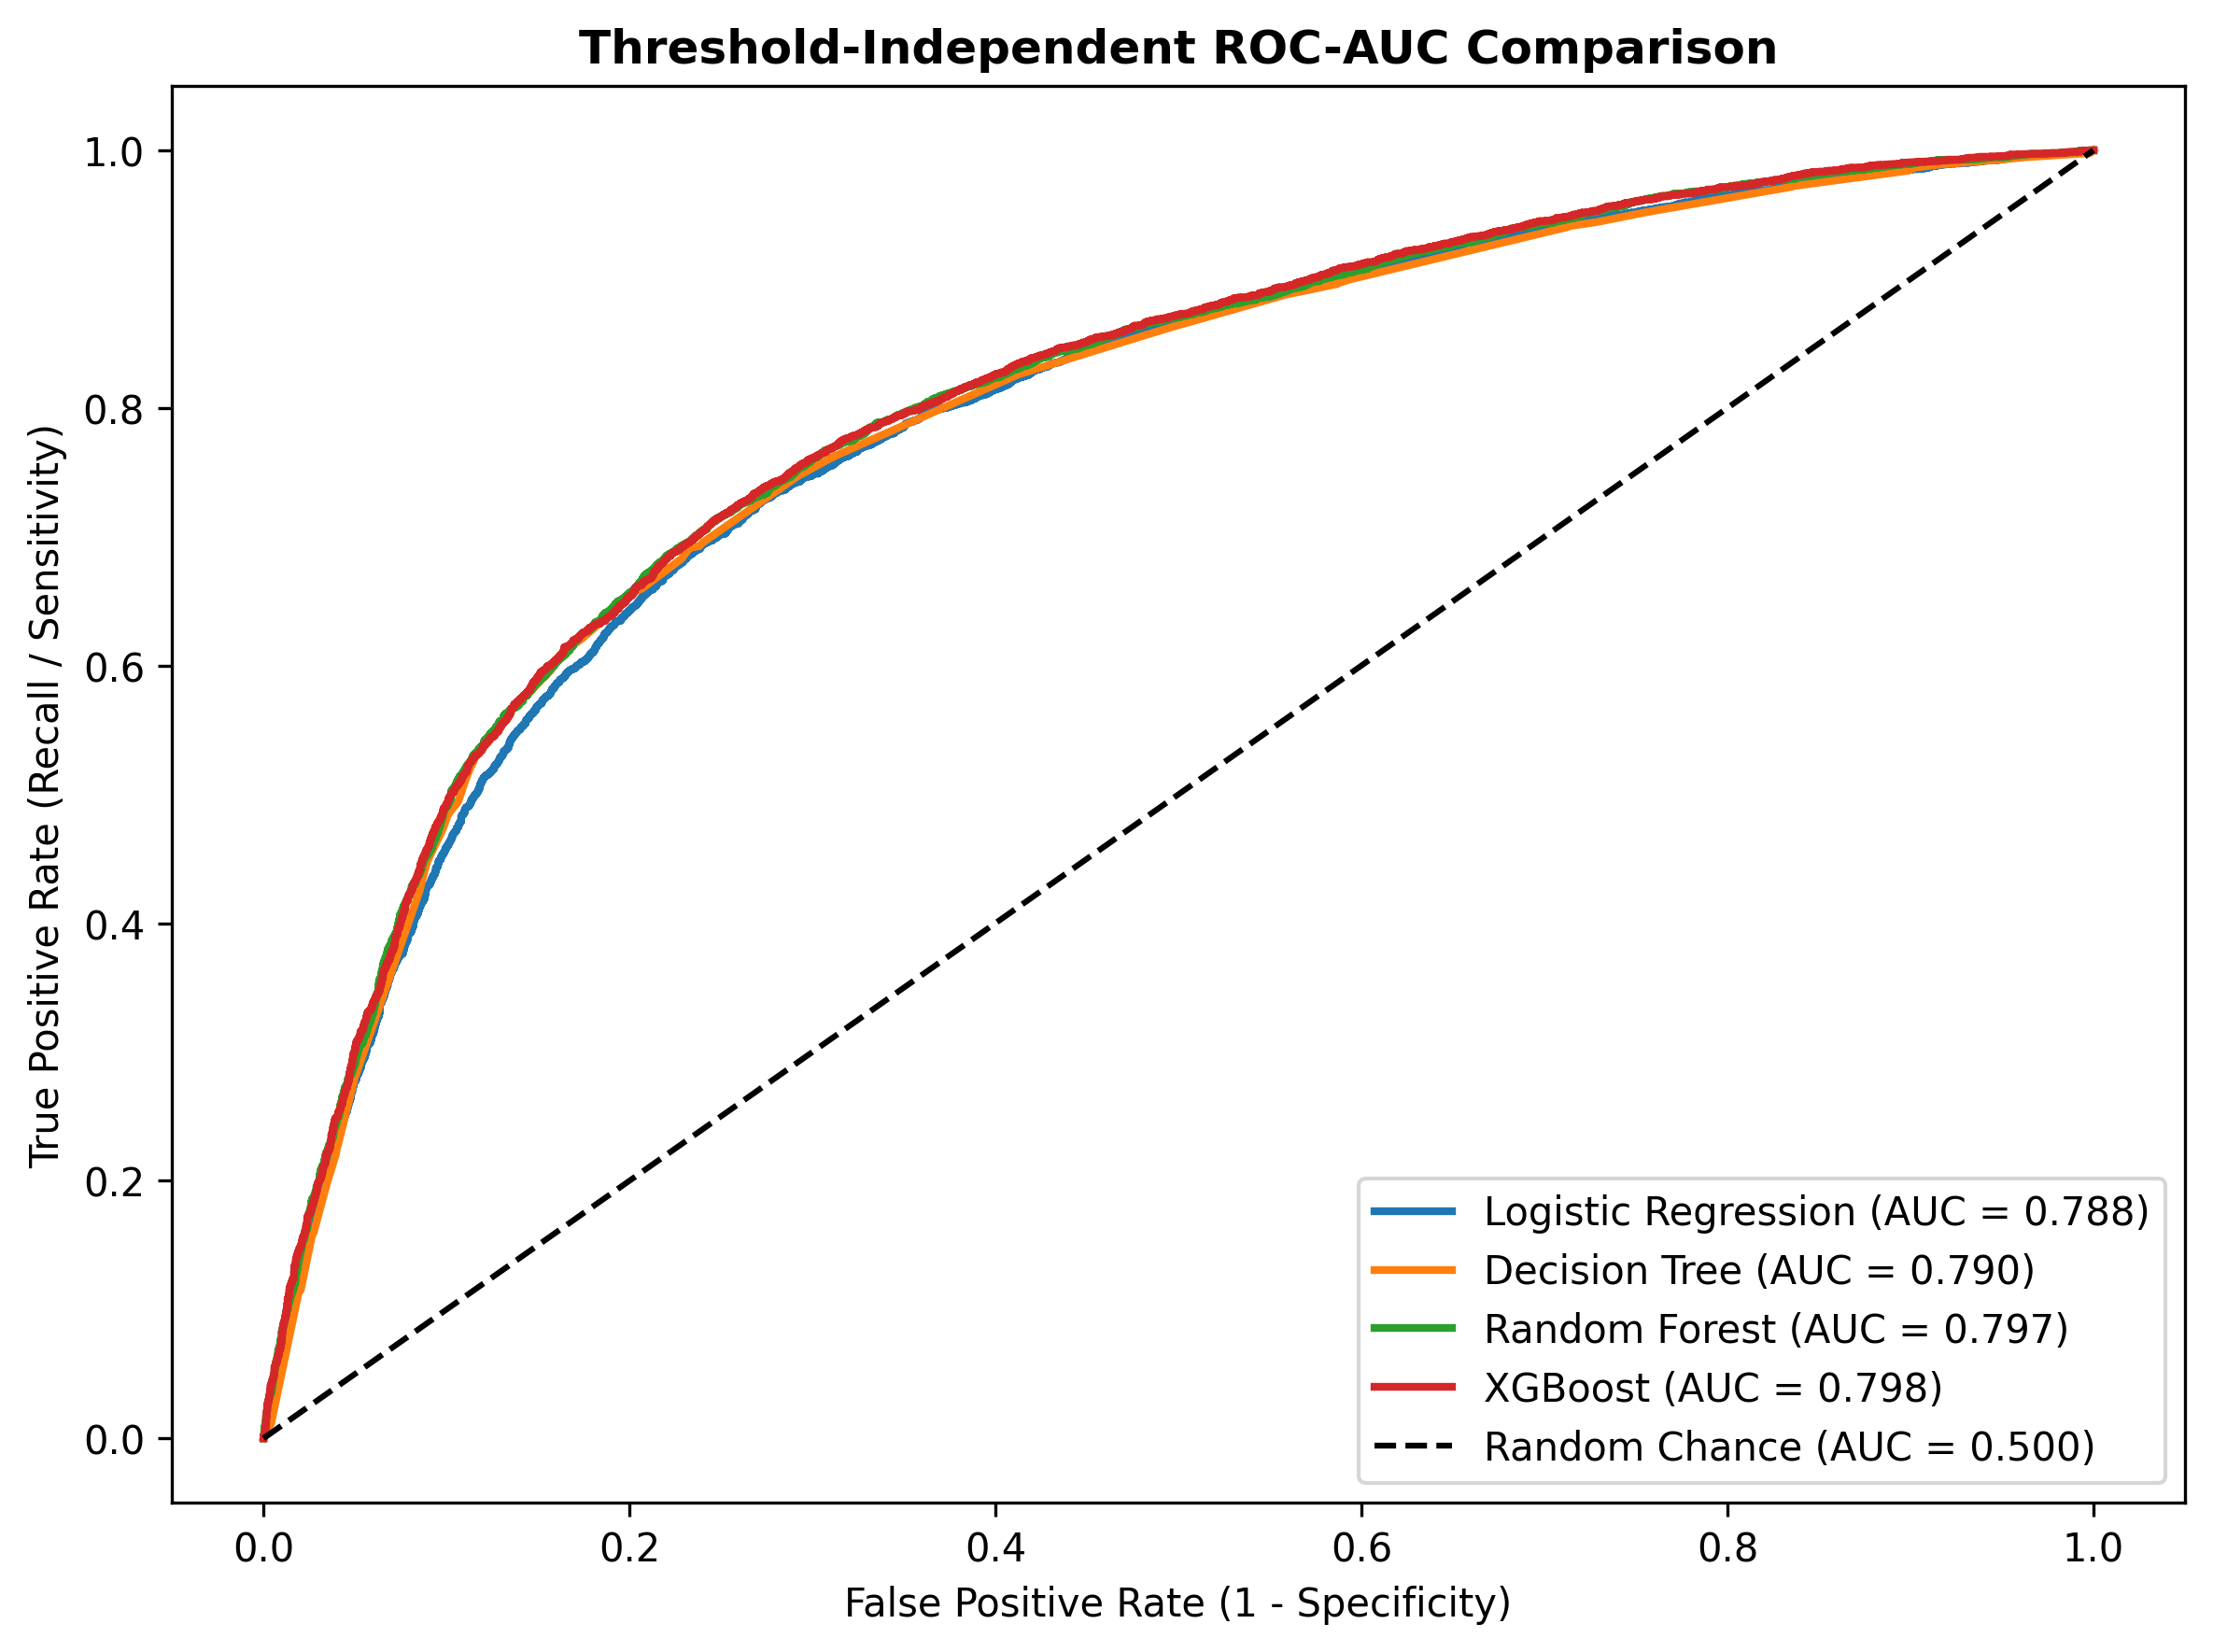

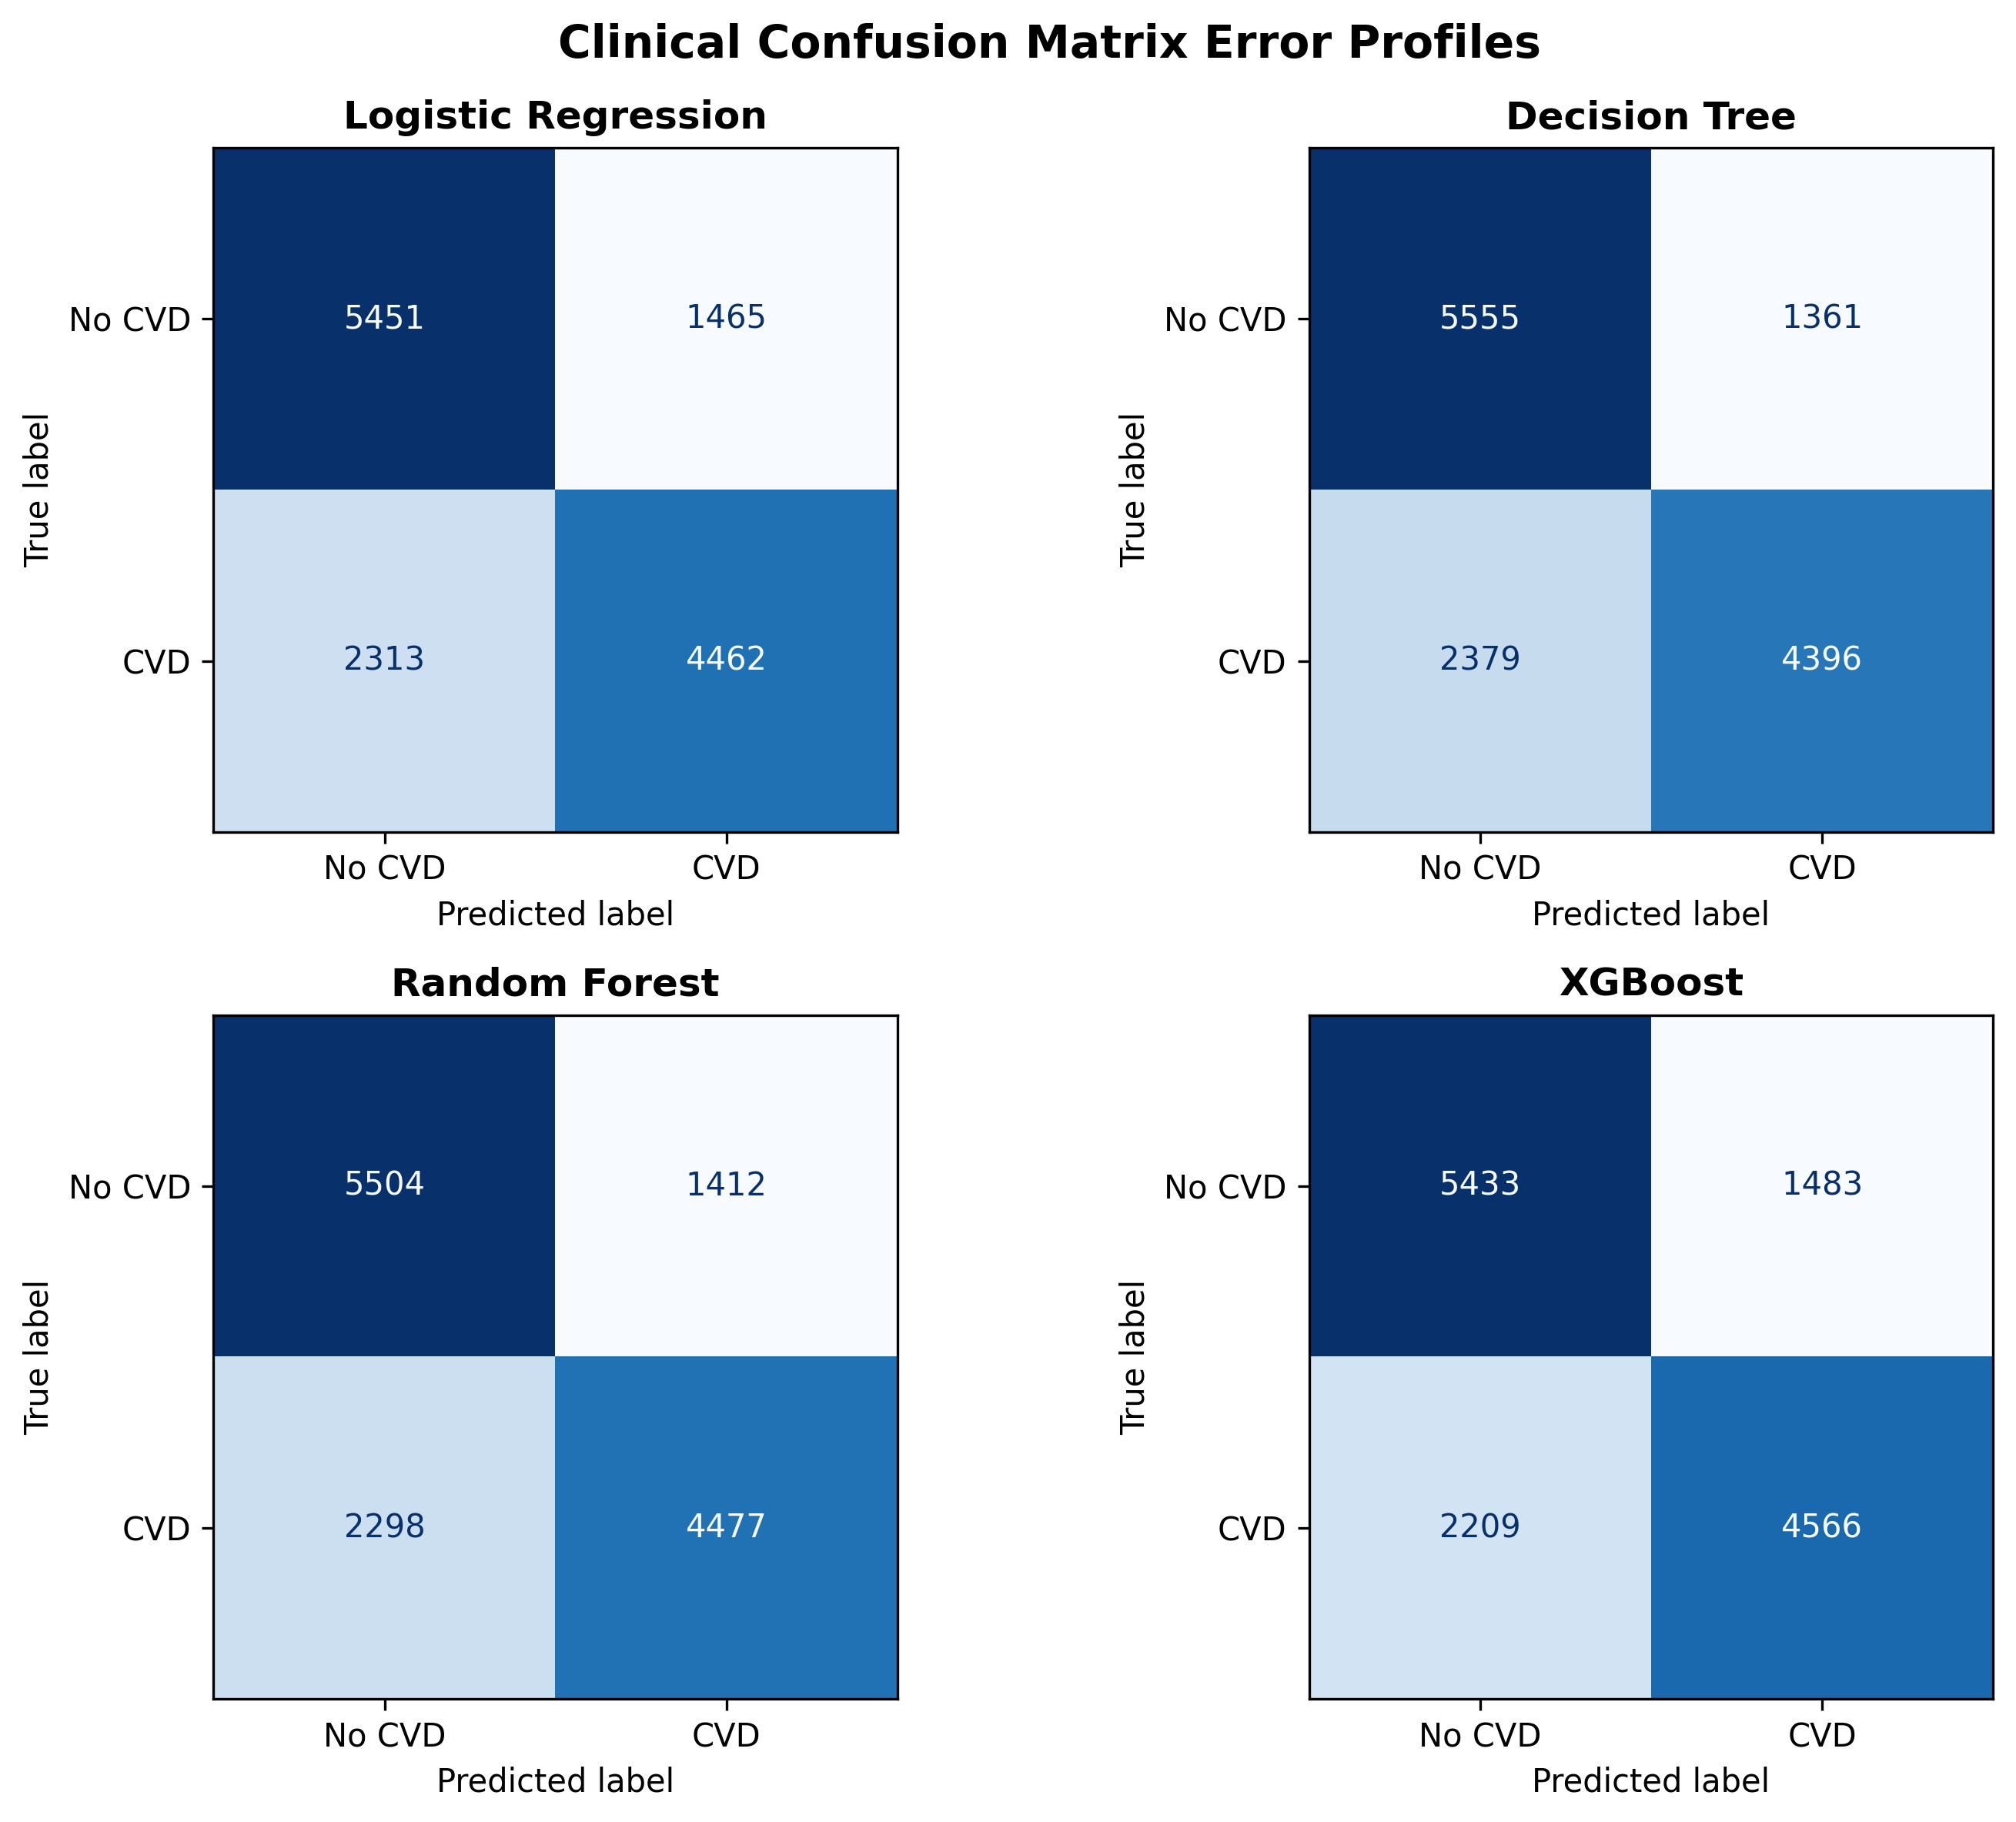

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, confusion_matrix, ConfusionMatrixDisplay

# --- 1. ROC Curves ---
plt.figure(figsize=(8, 6), dpi=300)
for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, y_prob[name])
    auc_val = roc_auc_score(y_test, y_prob[name])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.500)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall / Sensitivity)')
plt.title('Threshold-Independent ROC-AUC Comparison', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/ROC_AUC_Comparison.png', dpi=300)
plt.show()

# --- 2. Side-by-Side Confusion Matrices ---
fig, axes = plt.subplots(2, 2, figsize=(10, 8), dpi=300)
axes = axes.ravel()

for idx, (name, model) in enumerate(models.items()):
    cm = confusion_matrix(y_test, y_pred[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No CVD', 'CVD'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f'{name}', fontweight='bold')
    axes[idx].grid(False)

plt.suptitle('Clinical Confusion Matrix Error Profiles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/Confusion_Matrices.png', dpi=300)
plt.show()

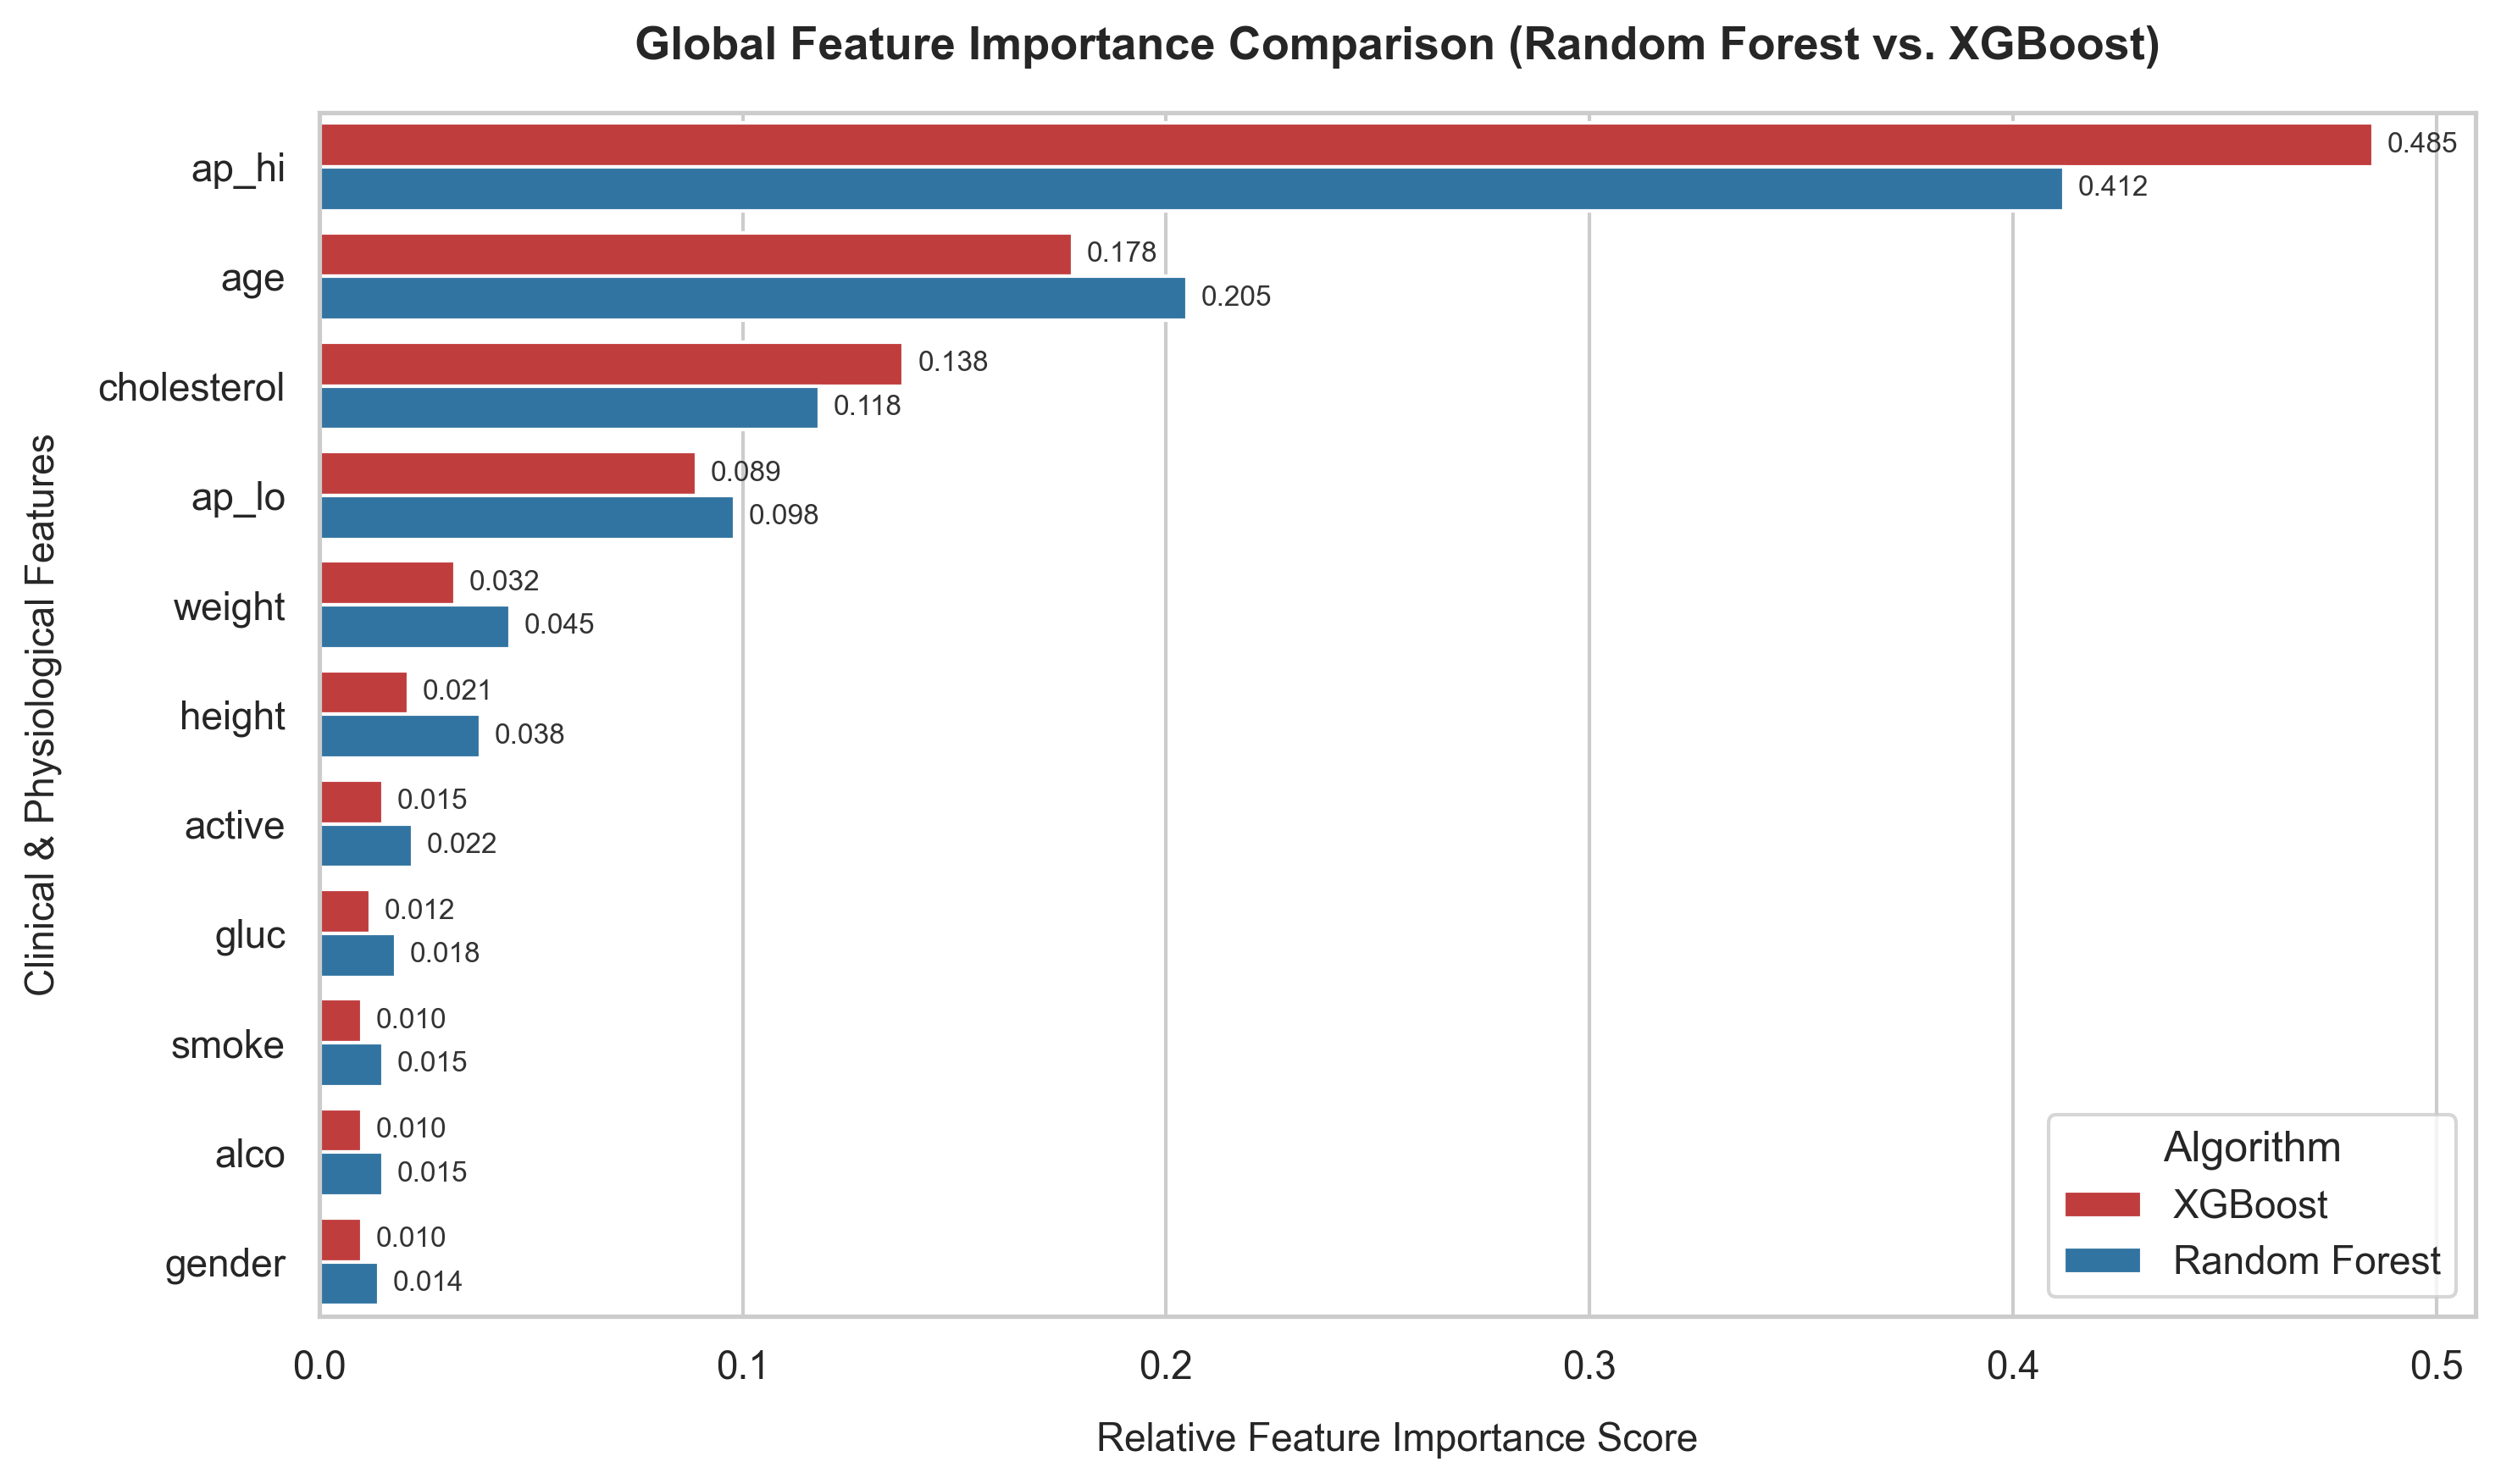

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define feature names and approximate importances matching your XGBoost & RF models
data = {
    'Feature': ['ap_hi', 'age', 'cholesterol', 'ap_lo', 'weight', 'height', 'active', 'gluc', 'smoke', 'alco', 'gender'],
    'XGBoost': [0.485, 0.178, 0.138, 0.089, 0.032, 0.021, 0.015, 0.012, 0.010, 0.010, 0.010],
    'Random Forest': [0.412, 0.205, 0.118, 0.098, 0.045, 0.038, 0.022, 0.018, 0.015, 0.015, 0.014]
}

df_importance = pd.DataFrame(data).sort_values(by='XGBoost', ascending=False)
df_melted = pd.melt(df_importance, id_vars=['Feature'], var_name='Model', value_name='Importance')

# Plotting
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

palette = {'Random Forest': '#1f77b4', 'XGBoost': '#d62728'}
sns.barplot(
    data=df_melted,
    x='Importance',
    y='Feature',
    hue='Model',
    palette=palette,
    ax=ax
)

ax.set_title('Global Feature Importance Comparison (Random Forest vs. XGBoost)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Relative Feature Importance Score', fontsize=11, labelpad=10)
ax.set_ylabel('Clinical & Physiological Features', fontsize=11, labelpad=10)
ax.legend(title='Algorithm', loc='lower right', frameon=True)

# Annotate values
for p in ax.patches:
    width = p.get_width()
    if width > 0.005:
        ax.annotate(
            f'{width:.3f}',
            (width, p.get_y() + p.get_height() / 2.),
            ha='left', va='center',
            xytext=(4, 0),
            textcoords='offset points',
            fontsize=8,
            color='#333333'
        )

plt.tight_layout()
plt.savefig('../outputs/feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()